# Check how naive approach would fit
## Task: KAN-35

In this notebook we would check how the basic fingerprints of moleculers works using classic ML models in the task of prediction absorptium spectrum.

In [1]:
import os
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In this notebook the model will be train on 3 simple 3D fingerprints:
1. Coulomb Matrix
2. Bob (Bag of Bonds)
3. SOAT

Enough simple to be a good benchmark, enough advance to not ignore the 3D representation

Imports:

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) # As all things should be :)

import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, HalvingRandomSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from typing import Callable, Dict
from gjepa.datasets.cv_vis.tmqmg_star import TMQMGStarDataset
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
from torch_geometric.loader import DataLoader
from scipy.stats import uniform, randint, loguniform
import shap

from gjepa.datasets.cv_vis.tmqmg_star import TMQMGStarDataset



## Coulomb Fingerprint

For each molecule (record) in your dataset:

$$
C_{ij} = \frac{Z_i Z_j}{|| R_i - R_j ||}
$$
Where 

$ Z_i $ - atomic number

$ R_i $ - 3-vector of atomic coordinates


Then we’ll flatten or sort the matrix so we can feed it into a machine-learning model.

Here is an implementation of transforming record for a coulomb fingerprint representation.

In [3]:
def compute_coulomb_matrix(z, pos):
    if not torch.is_tensor(z):
        z = torch.tensor(z, dtype=torch.float32)
    if not torch.is_tensor(pos):
        pos = torch.tensor(pos, dtype=torch.float32)

    N = z.numel()
    pos = pos.view(N, 3)

    dist = torch.cdist(pos, pos, p=2)
    Z = z.view(-1, 1)

    CM = torch.where(dist > 1e-8, Z * Z.T / dist, torch.zeros_like(dist))

    diag_vals = 0.5 * (z ** 2.4)
    CM[range(N), range(N)] = diag_vals

    return CM


def coulomb_fingerprint(z: torch.Tensor, pos: torch.Tensor, max_atoms=60) -> np.ndarray:
    CM = compute_coulomb_matrix(z, pos)
    N = CM.size(0)
    if N < max_atoms:
        padded = torch.zeros((max_atoms, max_atoms))
        padded[:N, :N] = CM
        CM = padded
    elif N > max_atoms:
        CM = CM[:max_atoms, :max_atoms]
    return CM.flatten().numpy()

def coulomb_fingerprint_with_labels(z, pos, max_atoms=60, include_diagonal=True):
    if not torch.is_tensor(z):
        z = torch.tensor(z, dtype=torch.float32)
    if not torch.is_tensor(pos):
        pos = torch.tensor(pos, dtype=torch.float32)

    N = z.numel()
    pos = pos.view(N, 3)
    dist = torch.cdist(pos, pos, p=2)
    Z = z.view(-1, 1)

    CM = torch.where(dist > 1e-8, Z * Z.T / dist, torch.zeros_like(dist))
    diag_vals = 0.5 * (z ** 2.4)
    CM[range(N), range(N)] = diag_vals

    if N < max_atoms:
        padded = torch.zeros((max_atoms, max_atoms))
        padded[:N, :N] = CM
        CM = padded
        padded_dist = torch.zeros((max_atoms, max_atoms))
        padded_dist[:N, :N] = dist
        dist = padded_dist
        z_full = torch.zeros(max_atoms)
        z_full[:N] = z
        z = z_full
    elif N > max_atoms:
        CM = CM[:max_atoms, :max_atoms]
        dist = dist[:max_atoms, :max_atoms]
        z = z[:max_atoms]

    k = 0 if include_diagonal else 1
    i_idx, j_idx = np.triu_indices(max_atoms, k=k)
    CM_vec = CM[i_idx, j_idx].numpy()

    labels = []
    for i, j in zip(i_idx, j_idx):
        Zi, Zj = int(z[i].item()), int(z[j].item())
        dij = float(dist[i, j].item())
        labels.append(f"{i}-{j}_Z{Zi}_Z{Zj}_d{dij:.2f}")

    return CM_vec, labels


Dataset would be transform to each fingerprint using:

In [4]:
class FingerprintTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, dataset_config: Dict, fingerprint_fn: Callable, max_atoms: int = 60):
        self.dataset_config = dataset_config
        self.fingerprint_fn = fingerprint_fn
        self.max_atoms = max_atoms

    def fit(self, X=None, y=None):
        return self

    def transform(self, X=None):
        dataset = TMQMGStarDataset(**self.dataset_config)
        fingerprints, targets = [], []
        for d in dataset:
            f = self.fingerprint_fn(d.z, d.pos, self.max_atoms)
            fingerprints.append(f)
            targets.append(d.y.flatten().numpy())
        self.X_ = np.vstack(fingerprints)
        self.Y_ = np.vstack(targets)
        return self.X_


Because of the problem of the high number of input dimensions, we will use PCA for reducing them:

In [5]:
class VarianceCutoff(BaseEstimator, TransformerMixin):
    def __init__(self, min_variance=0.99, show_plots=True):
        self.min_variance = min_variance
        self.show_plots = show_plots
        self.scaler = StandardScaler()
        self.selected_features_ = None
        self.threshold_ = None

    def fit(self, X, y=None):
        X_scaled = self.scaler.fit_transform(X)
        variances = np.var(X_scaled, axis=0)
        sorted_vars = np.sort(variances)[::-1]
        cum_var = np.cumsum(sorted_vars) / np.sum(sorted_vars)
        n_keep = np.argmax(cum_var >= self.min_variance) + 1
        self.threshold_ = sorted_vars[n_keep - 1]
        self.selected_features_ = np.where(variances >= self.threshold_)[0]

        if self.show_plots:
            plt.figure(figsize=(8, 6))
            plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='--')
            plt.axvline(n_keep, color='r', linestyle='--', 
                        label=f'{self.min_variance:.0%} variance ({n_keep} features)')
            plt.title('Cumulative Variance (Feature-wise)')
            plt.xlabel('Number of Features Kept')
            plt.ylabel('Cumulative Variance')
            plt.legend()
            plt.grid(True)
            plt.show()

        print(f"[INFO] Keeping {len(self.selected_features_)} of {X.shape[1]} features "
              f"({100 * len(self.selected_features_) / X.shape[1]:.1f}%)")

        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        return X_scaled[:, self.selected_features_]


class VisualPCA(BaseEstimator, TransformerMixin):
    def __init__(self, min_variance=0.95, show_plots=True):
        self.min_variance = min_variance
        self.show_plots = show_plots
        self.scaler = StandardScaler()
        self.pca = None
        self.n_components_ = None

    def fit(self, X, y=None):
        X_scaled = self.scaler.fit_transform(X)
        pca_full = PCA()
        pca_full.fit(X_scaled)
        explained = np.cumsum(pca_full.explained_variance_ratio_)
        self.n_components_ = np.argmax(explained >= self.min_variance) + 1

        if self.show_plots:
            plt.figure(figsize=(8, 6))
            plt.plot(range(1, len(explained)+1), explained, marker='o', linestyle='--')
            plt.axvline(self.n_components_, color='r', linestyle='--', 
                        label=f'{self.min_variance:.0%} variance ({self.n_components_} comps)')
            plt.title('Cumulative Explained Variance')
            plt.xlabel('Principal Component')
            plt.ylabel('Cumulative Variance')
            plt.legend()
            plt.grid(True)
            plt.show()

        self.pca = PCA(n_components=self.n_components_).fit(X_scaled)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        X_pca = self.pca.transform(X_scaled)
        return X_pca

Here is the pipeling we will use to for each experiment:

In [22]:
def analyze_dataset_outputs(dataset_config, fingerprint_fn=None, atoms_count=60, sample_limit=200):
    dataset = TMQMGStarDataset(**dataset_config)
    Y = []

    for i, d in enumerate(dataset):
        y_vec = np.array(d.y).flatten()
        Y.append(y_vec)
        if i >= sample_limit:
            break

    Y = np.vstack(Y)
    print(f"[INFO] Output shape: {Y.shape}")
    print(f'[INFO] Example input: {dataset[0]}')

    df_stats = pd.DataFrame(Y)
    print("\n=== Output Statistics ===")
    print(df_stats.describe().T[["min", "max", "mean", "std", "50%"]])

    zero_mask = (np.abs(Y[:, 1]) < 1e-8)
    zeros_ratio = zero_mask.sum() / Y.shape[0] * 100
    print(f"\nZeros or near-zeros in 2nd param (<1e-8): {zeros_ratio:.2f}%")

    y2 = Y[:, 1]
    plt.figure(figsize=(8,4))
    sns.histplot(y2, bins=100, kde=True)
    plt.title("Distribution of 2nd Output Parameter")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    sns.boxplot(x=y2)
    plt.title("Boxplot of 2nd Output Parameter")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    sns.violinplot(x=y2)
    plt.title("Violin Plot of 2nd Output Parameter")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    sns.histplot(y2[y2 > 0], bins=100, kde=True, log_scale=True)
    plt.title("Log-Scaled Distribution (Positive Values Only)")
    plt.xlabel("Value (log scale)")
    plt.tight_layout()
    plt.show()

    outlier_thresh = y2.mean() + 3 * y2.std()
    outliers = y2[y2 > outlier_thresh]
    print(f"\nOutliers (> mean + 3σ): {len(outliers)} samples ({len(outliers)/len(y2)*100:.2f}%)")
    print(f"Outlier range: min={outliers.min() if len(outliers)>0 else '—'}, max={outliers.max() if len(outliers)>0 else '—'}")

    return {
        "Y": Y,
        "y2": y2,
        "zero_ratio": zeros_ratio,
        "stats": df_stats.describe(),
        "outliers": outliers
    }


/tmp/ipykernel_4315/1978794154.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


[INFO] Output shape: (201, 2)
[INFO] Example input: Data(y=[1, 2], pos=[45, 3], z=[45], smiles='', origin_id='DASFIQ', CSD_code='DASFIQ')

=== Output Statistics ===
     min         max        mean       std         50%
0  381.0  705.469971  458.347260  63.10474  450.540009
1    0.0    0.788100    0.048701   0.13505    0.005800

Zeros or near-zeros in 2nd param (<1e-8): 2.99%


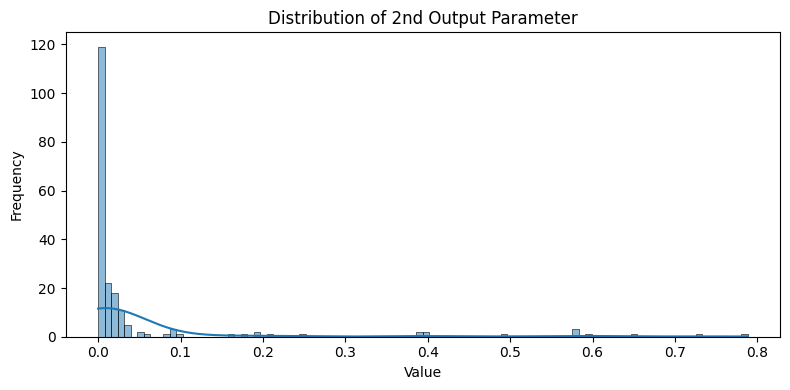

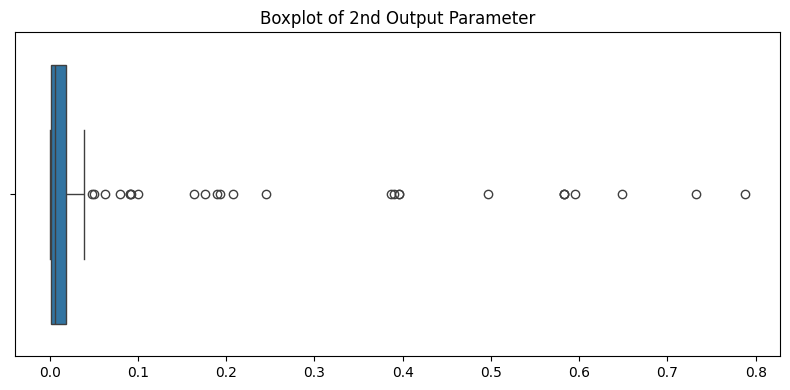

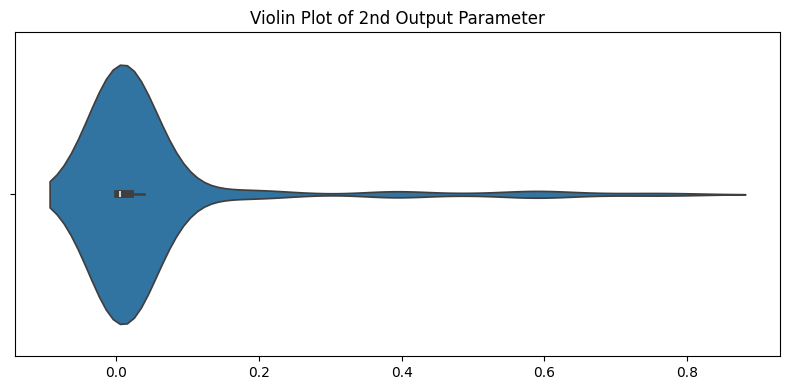

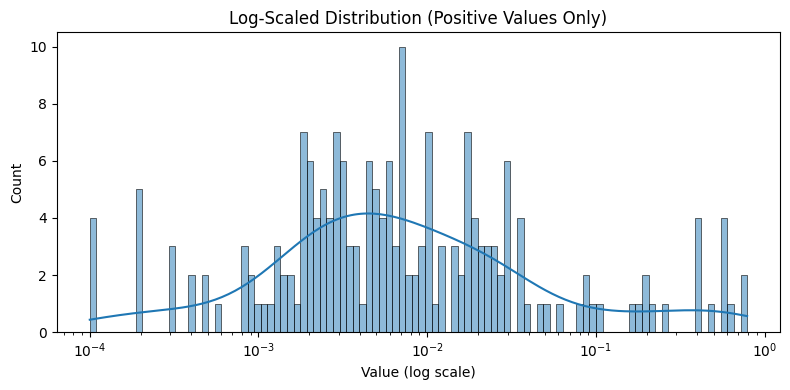


Outliers (> mean + 3σ): 8 samples (3.98%)
Outlier range: min=0.49630001187324524, max=0.788100004196167


In [23]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 1,
    'filter_states': 10,
    'pre_transform': None
}

dataset_analysis = analyze_dataset_outputs(
    dataset_config=dataset_config,
    fingerprint_fn=coulomb_fingerprint_with_labels,
    atoms_count=30 
)


It is worth trying to predict log y instead of y, as this seems to be an easier task.

In [9]:
def train_fixed_model(
    dataset_config,
    fingerprint_fn,
    model_params,
    output_type="vector",
    atoms_count=60,
    dimensions_cutoff=None,     
    show_plot=True,
    explain_with_shap=False,
    shap_sample_size=200
):
    dataset = TMQMGStarDataset(**dataset_config)
    X, Y = [], []
    labels_ref = None

    for d in dataset:
        fp_vec, fp_labels = fingerprint_fn(d.z, d.pos, atoms_count)
        X.append(fp_vec)
        y_vec = np.array(d.y).flatten()
        Y.append(y_vec)
        if labels_ref is None:
            labels_ref = fp_labels 

    min_len = min(len(y) for y in Y)
    Y = [y[:min_len] for y in Y]
    X, Y = np.vstack(X), np.vstack(Y)

    print(f"[INFO] Dataset shapes: X={X.shape}, Y={Y.shape}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_test = x_scaler.transform(X_test)
    y_train = y_scaler.fit_transform(y_train)
    y_test = y_scaler.transform(y_test)

    print("[INFO] Applied StandardScaler normalization (fit on train only)")

    if dimensions_cutoff is not None:
        X_train = dimensions_cutoff.fit_transform(X_train)
        X_test = dimensions_cutoff.transform(X_test)
        print(f"[INFO] Applied VarianceCutoff → new shape: {X_train.shape}")

    base_model = MultiOutputRegressor(
        XGBRegressor(
            tree_method="hist",
            n_jobs=-1,
            random_state=42,
            verbosity=0,
            **model_params
        )
    )

    print(f"[INFO] Training final fixed model for '{output_type}' ...")
    base_model.fit(X_train, y_train)

    y_pred = base_model.predict(X_test)
    # Evaluate both on scaled data (consistent with search)
    r2 = r2_score(y_test, y_pred, multioutput='uniform_average')
    mae = mean_absolute_error(y_test, y_pred)
    print(f"\n[RESULTS - standardized space] R2={r2:.3f} | MAE={mae:.3f}")

    # Also compute metrics in physical (inverse-scaled) space
    y_pred_inv = y_scaler.inverse_transform(y_pred)
    y_test_inv = y_scaler.inverse_transform(y_test)
    r2_inv = r2_score(y_test_inv, y_pred_inv, multioutput='uniform_average')
    mae_inv = mean_absolute_error(y_test_inv, y_pred_inv)
    print(f"[RESULTS - physical space]     R2={r2_inv:.3f} | MAE={mae_inv:.3f}")

    # --- Per-output diagnostics ---
    per_target_r2 = []
    per_target_mae = []
    for j in range(y_test.shape[1]):
        r2_j = r2_score(y_test[:, j], y_pred[:, j])
        mae_j = mean_absolute_error(y_test[:, j], y_pred[:, j])
        per_target_r2.append(r2_j)
        per_target_mae.append(mae_j)

    summary = pd.DataFrame({
        "Output_Index": np.arange(len(per_target_r2)),
        "R2": per_target_r2,
        "MAE": per_target_mae
    })

    if show_plot:
        fig, axes = plt.subplots(3, 1, figsize=(10, 10))
        sns.barplot(x="Output_Index", y="R2", data=summary, ax=axes[0], color="skyblue")
        axes[0].set_title("R² per Output Dimension")
        axes[0].set_ylabel("R²")

        sns.barplot(x="Output_Index", y="MAE", data=summary, ax=axes[1], color="salmon")
        axes[1].set_title("MAE per Output Dimension")
        axes[1].set_ylabel("MAE")

        abs_errors = np.abs(y_test - y_pred)
        sns.heatmap(abs_errors.T, ax=axes[2], cmap="Reds", cbar=True)
        axes[2].set_title("Absolute Error Heatmap (test set)")
        axes[2].set_xlabel("Sample Index")
        axes[2].set_ylabel("Output Dimension")

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 6))
        plt.scatter(y_test.flatten(), y_pred.flatten(), s=5, alpha=0.4, color='darkgreen')
        plt.xlabel("True (scaled)")
        plt.ylabel("Predicted (scaled)")
        plt.title(f"{output_type.capitalize()} Prediction Scatter\nR²={r2:.3f}")
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.show()

    print(f"\nAverage per-output R²: {np.mean(per_target_r2):.3f}")
    print(summary.head(10))

    # --- Optional SHAP analysis ---
    if explain_with_shap:
        print("\n[INFO] Running SHAP analysis (on first output estimator)...")
        sample_size = min(shap_sample_size, len(X_test))
        X_sample = X_test[:sample_size]

        # Get one sub-estimator (for first output)
        model_0 = base_model.estimators_[0]
        explainer = shap.TreeExplainer(model_0)
        shap_values = explainer(X_sample)
        shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20)

    return {
        "model": base_model,
        "r2_scaled": r2,
        "mae_scaled": mae,
        "r2_original": r2_inv,
        "mae_original": mae_inv,
        "per_target_r2": per_target_r2,
        "per_target_mae": per_target_mae,
        "summary": summary,
        "scalers": {"x": x_scaler, "y": y_scaler},
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "labels": labels_ref
    }


In [10]:
def find_best_hyperparams_model_only(
    dataset_config,
    fingerprint_fn,
    output_type="pairs",
    atoms_count=60,
    dimensions_cutoff=None,
    n_candidates=50,
    show_plot=True
):
    dataset = TMQMGStarDataset(**dataset_config)
    X, Y = [], []
    labels_ref = None

    for d in dataset:
        fp_vec, fp_labels = fingerprint_fn(d.z, d.pos, atoms_count)
        X.append(fp_vec)
        y_vec = np.array(d.y).flatten()
        Y.append(y_vec)
        if labels_ref is None:
            labels_ref = fp_labels 
            
    min_len = min(len(y) for y in Y)
    Y = [y[:min_len] for y in Y]
    X, Y = np.vstack(X), np.vstack(Y)

    print(f"[INFO] Dataset shapes: X={X.shape}, Y={Y.shape}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_train = x_scaler.fit_transform(X_train)
    X_test = x_scaler.transform(X_test)
    y_train = y_scaler.fit_transform(y_train)
    y_test = y_scaler.transform(y_test)

    print("[INFO] Applied StandardScaler normalization (fit on train set only)")

    if dimensions_cutoff is not None:
        X_train = dimensions_cutoff.fit_transform(X_train)
        X_test = dimensions_cutoff.transform(X_test)
        print(f"[INFO] Applied VarianceCutoff → new shape: {X_train.shape}")

    base_model = MultiOutputRegressor(
        XGBRegressor(tree_method="hist", n_jobs=-1, random_state=42)
    )

    param_distributions = {
        'estimator__n_estimators': randint(200, 1200),
        'estimator__max_depth': randint(3, 14),
        'estimator__learning_rate': loguniform(1e-3, 0.2),
        'estimator__subsample': uniform(0.6, 0.4),
        'estimator__colsample_bytree': uniform(0.6, 0.4)
    }

    print(f"\n[INFO] Running HalvingRandomSearchCV (model-only) for '{output_type}'...")

    search = HalvingRandomSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        factor=3,
        n_candidates=n_candidates,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        scoring='r2'
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    y_pred_inv = y_scaler.inverse_transform(y_pred)
    y_test_inv = y_scaler.inverse_transform(y_test)

    r2 = r2_score(y_test_inv, y_pred_inv, multioutput='uniform_average')
    mae = mean_absolute_error(y_test_inv, y_pred_inv)

    print(f"\n Best hyperparameters for '{output_type}':")
    for k, v in search.best_params_.items():
        print(f"   {k}: {v}")
    print(f"R2: {r2:.3f} | MAE: {mae:.3f}")

    if show_plot:
        plt.figure(figsize=(5,5))
        plt.scatter(y_test_inv.flatten(), y_pred_inv.flatten(), s=5, alpha=0.4)
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title(f"{output_type.capitalize()} Model Search\nR2={r2:.3f}")
        plt.plot(
            [y_test_inv.min(), y_test_inv.max()],
            [y_test_inv.min(), y_test_inv.max()],
            'r--'
        )
        plt.show()

    cleaned_params = {k.replace("estimator__", ""): v for k, v in search.best_params_.items()}

    return {
        "best_params": cleaned_params,
        "r2": r2,
        "mae": mae,
        "model": best_model,
        "labels": labels_ref,
        "search_obj": search,
        "scalers": {"x": x_scaler, "y": y_scaler},
        "y_pred": y_pred_inv,
        "y_test": y_test_inv
    }


/tmp/ipykernel_5580/1529326861.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


[INFO] Dataset shapes: X=(12945, 465), Y=(12945, 2)
[INFO] Applied StandardScaler normalization (fit on train set only)

[INFO] Running HalvingRandomSearchCV (model-only) for 'pairs'...
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 7
min_resources_: 10
max_resources_: 10356
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 10
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resou

----------
iter: 1
n_candidates: 17
n_resources: 30
Fitting 5 folds for each of 17 candidates, totalling 85 fits
----------
iter: 2
n_candidates: 6
n_resources: 90
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 3
n_candidates: 2
n_resources: 270
Fitting 5 folds for each of 2 candidates, totalling 10 fits

 Best hyperparameters for 'pairs':
   estimator__colsample_bytree: 0.602208846849441
   estimator__learning_rate: 0.0752317574354701
   estimator__max_depth: 3
   estimator__n_estimators: 591
   estimator__subsample: 0.8916028672163949
R2: 0.358 | MAE: 30.166


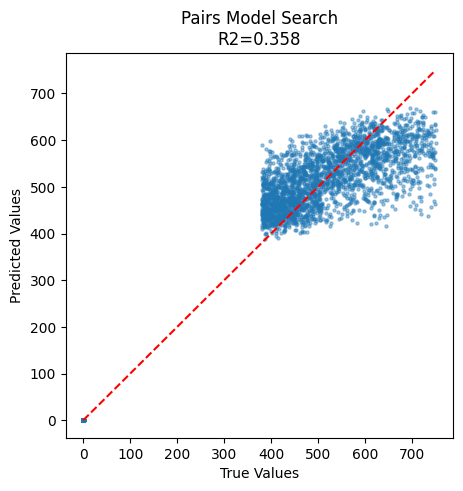

In [63]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 1,
    'filter_states': 10,
    'pre_transform': None
}

# Best hyperparameters for 'pairs':
#    estimator__colsample_bytree: 0.602208846849441
#    estimator__learning_rate: 0.0752317574354701
#    estimator__max_depth: 3
#    estimator__n_estimators: 591
#    estimator__subsample: 0.8916028672163949
# R2: 0.372 | MAE: 29.824
params = find_best_hyperparams_model_only(
    dataset_config=dataset_config,
    fingerprint_fn=coulomb_fingerprint_with_labels,
    output_type="pairs",
    atoms_count=30 
)


/tmp/ipykernel_5580/2336620063.py:33: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


[INFO] Dataset shapes: X=(12945, 465), Y=(12945, 2)
[INFO] Applied StandardScaler normalization (fit on train only)
[INFO] Training final fixed model for 'pairs' ...

[RESULTS - standardized space] R2=0.290 | MAE=0.467
[RESULTS - physical space]     R2=0.290 | MAE=30.269


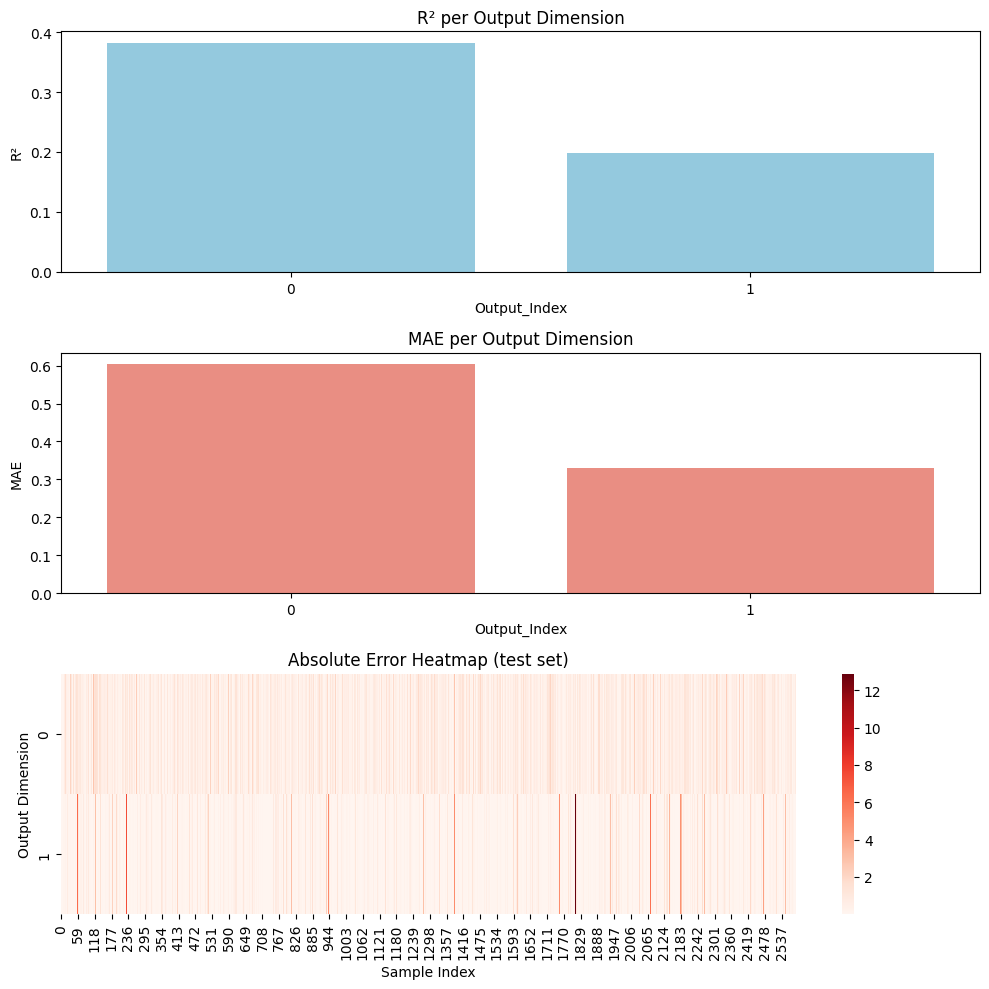

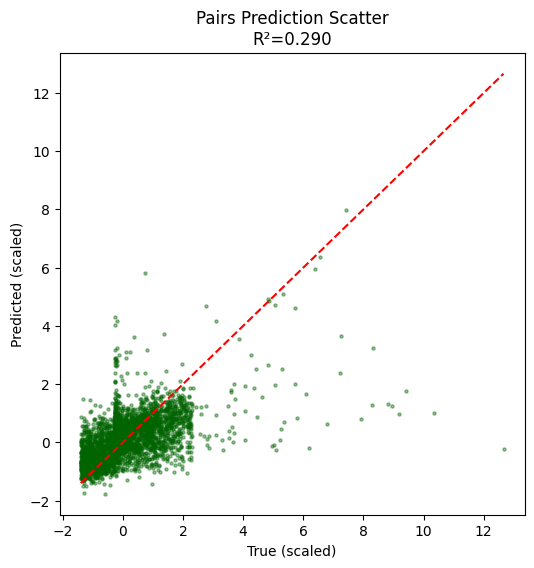


Average per-output R²: 0.290
   Output_Index        R2       MAE
0             0  0.382142  0.604404
1             1  0.197515  0.330086

=== FINAL RESULTS ===
R2: [0.38214194774627686, 0.19751453399658203]
MAE: [0.604404091835022, 0.3300856351852417]


In [52]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 1,
    'filter_states': 10,
    'pre_transform': None
}

results = train_fixed_model(
    dataset_config=dataset_config,
    fingerprint_fn=coulomb_fingerprint_with_labels,
    model_params=params,
    output_type="pairs",
    atoms_count=30
)

print("\n=== FINAL RESULTS ===")
print("R2:", results["per_target_r2"])
print("MAE:", results["per_target_mae"])


## Bag of Bound fingerprint

In [16]:
def bag_of_bonds_fingerprint_with_labels(z, pos, max_atoms=30, max_bonds_per_type=50):
    if not torch.is_tensor(z):
        z = torch.tensor(z, dtype=torch.float32)
    if not torch.is_tensor(pos):
        pos = torch.tensor(pos, dtype=torch.float32)

    N = z.numel()
    pos = pos.view(N, 3)
    dist = torch.cdist(pos, pos, p=2)
    Z = z.view(-1, 1)

    bond_values = {}
    for i in range(N):
        for j in range(i + 1, N):
            Zi, Zj = int(Z[i].item()), int(Z[j].item())
            key = tuple(sorted((Zi, Zj)))
            value = float((Zi * Zj) / dist[i, j].item()) if dist[i, j] > 1e-8 else 0.0
            bond_values.setdefault(key, []).append(value)

    all_types = sorted(bond_values.keys())
    bond_features = []
    labels = []

    for bond_type in all_types:
        vals = np.sort(np.array(bond_values[bond_type]))[::-1]
        padded = np.zeros(max_bonds_per_type)
        length = min(len(vals), max_bonds_per_type)
        padded[:length] = vals[:length]
        bond_features.extend(padded.tolist())

        for k in range(max_bonds_per_type):
            labels.append(f"Z{bond_type[0]}_Z{bond_type[1]}_pair_{k+1}")

    if len(bond_features) < max_atoms * max_bonds_per_type:
        bond_features += [0.0] * (max_atoms * max_bonds_per_type - len(bond_features))

    return np.array(bond_features[:max_atoms * max_bonds_per_type]), labels


/tmp/ipykernel_4315/3986023085.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 7
min_resources_: 10
max_resources_: 10356
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 10
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resou

----------
iter: 1
n_candidates: 17
n_resources: 30
Fitting 5 folds for each of 17 candidates, totalling 85 fits
----------
iter: 2
n_candidates: 6
n_resources: 90
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 3
n_candidates: 2
n_resources: 270
Fitting 5 folds for each of 2 candidates, totalling 10 fits


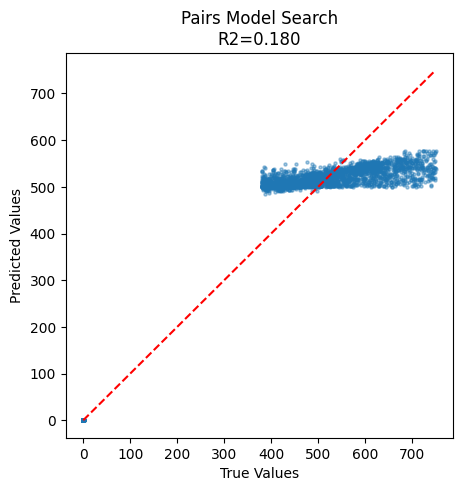

In [17]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 1,
    'filter_states': 10,
    'pre_transform': None
}

params_bob = find_best_hyperparams_model_only(
    dataset_config=dataset_config,
    fingerprint_fn=bag_of_bonds_fingerprint_with_labels,
    output_type="pairs",
    atoms_count=30 
)


/tmp/ipykernel_4315/2909737728.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


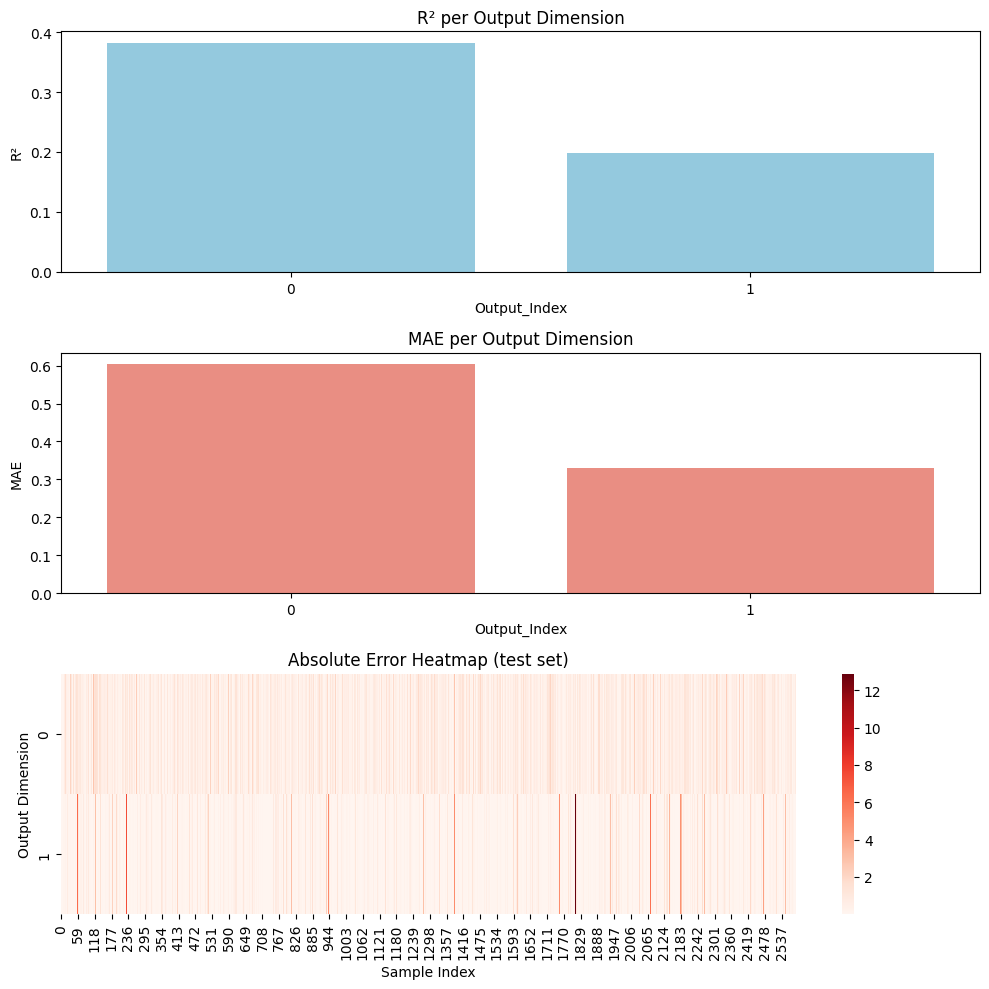

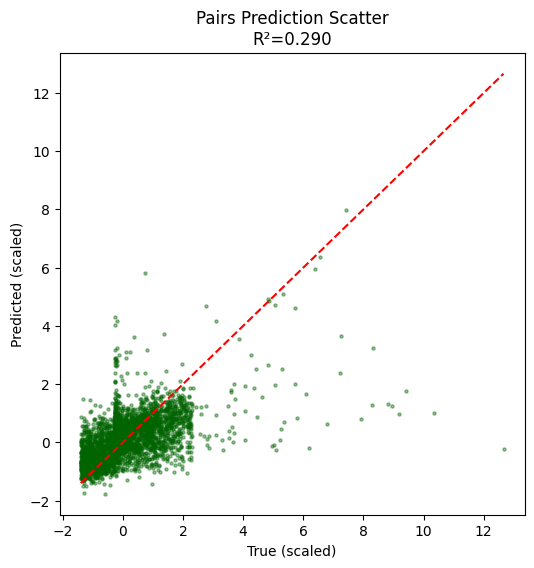


=== FINAL RESULTS ===
R2: [0.38214194774627686, 0.19751453399658203]
MAE: [0.604404091835022, 0.3300856351852417]


In [19]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 1,
    'filter_states': 10,
    'pre_transform': None
}

results_bob = train_fixed_model(
    dataset_config=dataset_config,
    fingerprint_fn=coulomb_fingerprint_with_labels,
    model_params=params_bob,
    output_type="pairs",
    atoms_count=30
)

print("\n=== FINAL RESULTS ===")
print("R2:", results_bob["per_target_r2"])
print("MAE:", results_bob["per_target_mae"])


## For 10 pairs

In [31]:
def analyze_dataset_outputs_10(dataset_config, sample_limit=500):
    dataset = TMQMGStarDataset(**dataset_config)

    Y = []

    for i, d in enumerate(dataset):
        y_vec = np.array(d.y).flatten()
        Y.append(y_vec)
        if i >= sample_limit:
            break

    Y = np.vstack(Y)

    print(f"[INFO] Output shape: {Y.shape}")
    print(f"[INFO] Example input: {dataset[0]}")

    odd_indices = list(range(1, Y.shape[1], 2))
    Y_odd = Y[:, odd_indices]

    print(f"\n[INFO] Analyzing odd indices: {odd_indices}")
    print(f"[INFO] Shape (odd-only): {Y_odd.shape}")

    df_stats = pd.DataFrame(Y_odd, columns=[f"y{i}" for i in odd_indices])
    print("\n=== Odd Output Statistics ===")
    print(df_stats.describe().T[["min", "max", "mean", "std", "50%"]])

    zero_ratios = {}
    for j, idx in enumerate(odd_indices):
        y_j = Y_odd[:, j]
        zero_ratios[idx] = (np.abs(y_j) < 1e-8).sum() / len(y_j) * 100

    print("\n=== Zero / Near-Zero Percentages (Odd Dimensions) ===")
    for idx in odd_indices:
        print(f"y{idx}: {zero_ratios[idx]:.2f}%")

    for j, idx in enumerate(odd_indices):
        y_j = Y_odd[:, j]

        plt.figure(figsize=(8,4))
        sns.histplot(y_j, bins=100, kde=True)
        plt.title(f"Distribution of y{idx}")
        plt.xlabel(f"y{idx}")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8,3))
        sns.boxplot(x=y_j)
        plt.title(f"Boxplot of y{idx}")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8,3))
        sns.violinplot(x=y_j)
        plt.title(f"Violin Plot of y{idx}")
        plt.tight_layout()
        plt.show()

        positive = y_j[y_j > 0]
        if len(positive) > 0:
            plt.figure(figsize=(8,4))
            sns.histplot(positive, bins=100, kde=True, log_scale=True)
            plt.title(f"Log-Scaled Histogram of y{idx} (positive values)")
            plt.tight_layout()
            plt.show()

        outlier_thresh = y_j.mean() + 3 * y_j.std()
        outliers = y_j[y_j > outlier_thresh]
        print(f"\nOutliers y{idx} (> mean + 3σ): {len(outliers)} samples "
              f"({len(outliers)/len(y_j)*100:.2f}%)")
        if len(outliers) > 0:
            print(f"Range: min={outliers.min():.4f}, max={outliers.max():.4f}")
        else:
            print("Range: —")

    return {
        "Y": Y,
        "Y_odd": Y_odd,
        "odd_indices": odd_indices,
        "stats": df_stats.describe(),
        "zero_ratios": zero_ratios
    }


/tmp/ipykernel_4315/4186730510.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


[INFO] Output shape: (320, 20)
[INFO] Example input: Data(y=[1, 20], pos=[35, 3], z=[35], smiles='[C-3]P1(#[C-])CCP([C-3])(#[C-])->[V+17]<-12(<-[C-]#[O+])(<-[C-]#[O+])(<-N#CC)<-P([C-3])(#[C-])CCP->2([C-3])#[C-]', origin_id='FUGNAW', CSD_code='FUGNAW')

[INFO] Analyzing odd indices: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
[INFO] Shape (odd-only): (320, 10)

=== Odd Output Statistics ===
     min     max      mean       std      50%
y1   0.0  0.4520  0.024031  0.076301  0.00065
y3   0.0  0.4555  0.031498  0.092085  0.00120
y5   0.0  0.6063  0.027188  0.080669  0.00225
y7   0.0  0.4491  0.023557  0.062275  0.00230
y9   0.0  0.2023  0.019117  0.037722  0.00260
y11  0.0  0.5355  0.021287  0.044180  0.00420
y13  0.0  1.4507  0.032210  0.126215  0.00400
y15  0.0  1.3138  0.036119  0.113852  0.00440
y17  0.0  1.4307  0.043149  0.145988  0.00430
y19  0.0  1.1610  0.033212  0.102974  0.00520

=== Zero / Near-Zero Percentages (Odd Dimensions) ===
y1: 19.38%
y3: 15.00%
y5: 14.06%
y7: 13.75%
y9: 12.50%

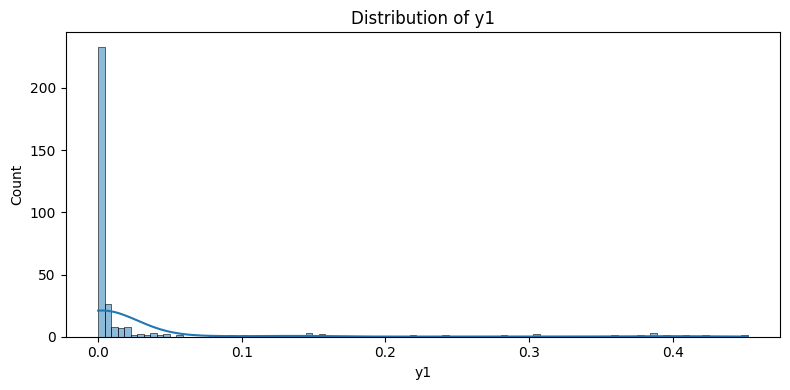

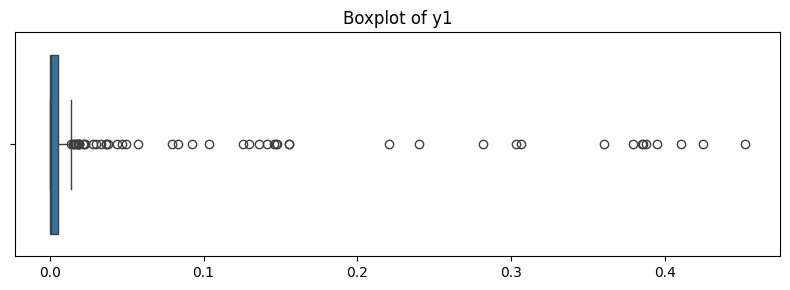

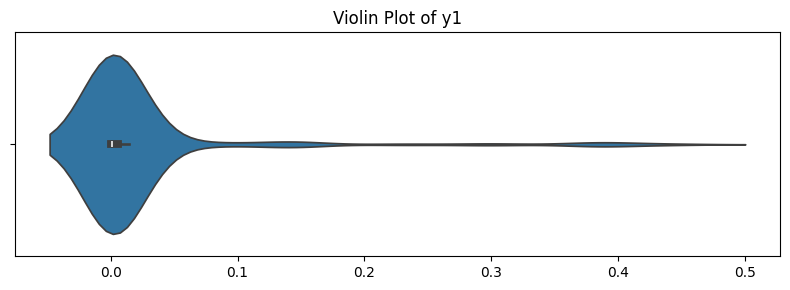

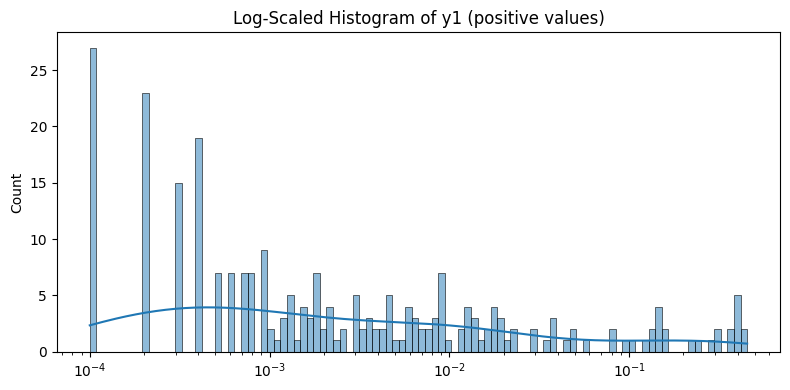


Outliers y1 (> mean + 3σ): 12 samples (3.75%)
Range: min=0.2817, max=0.4520


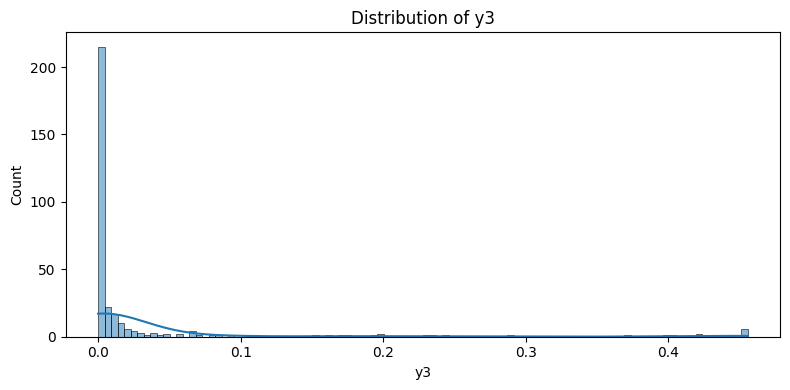

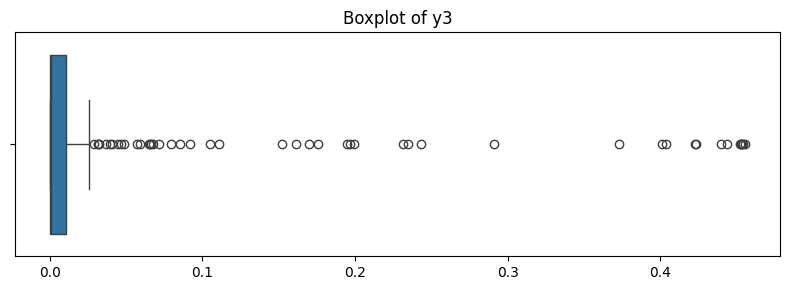

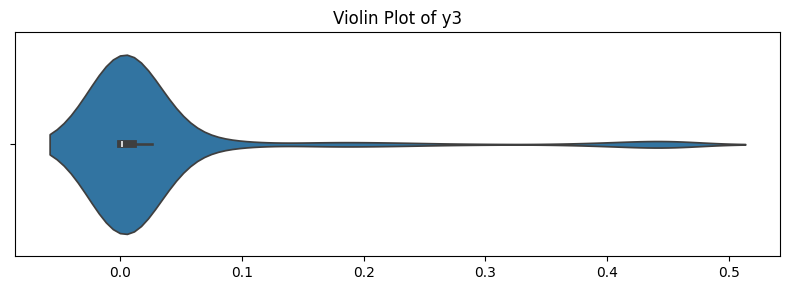

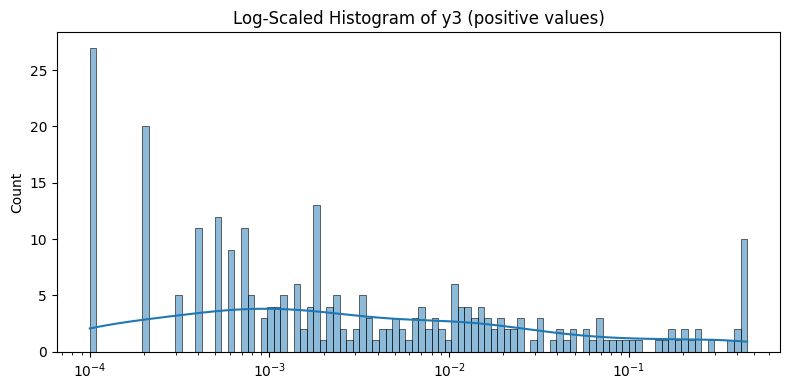


Outliers y3 (> mean + 3σ): 13 samples (4.06%)
Range: min=0.3728, max=0.4555


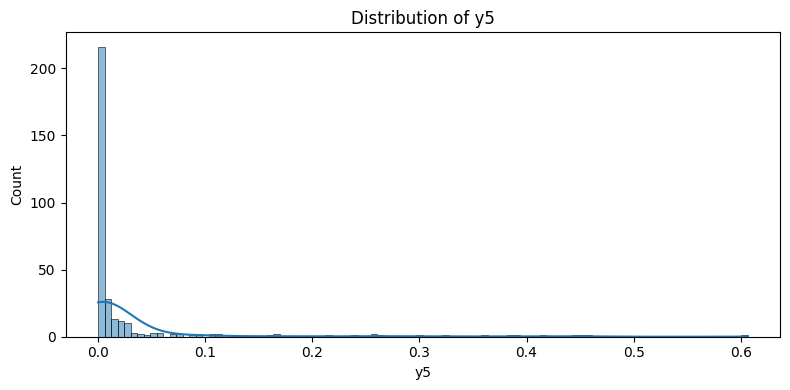

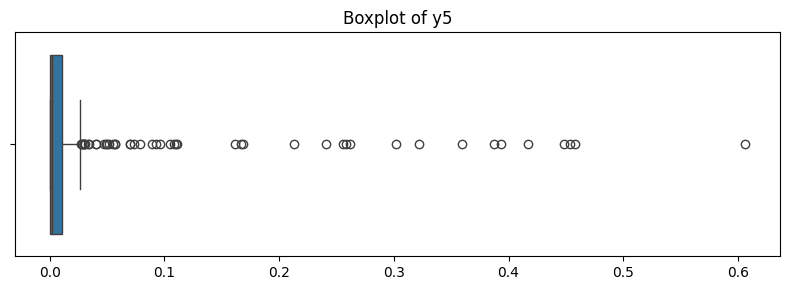

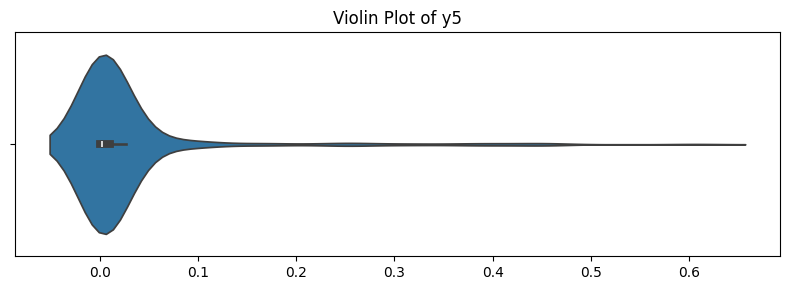

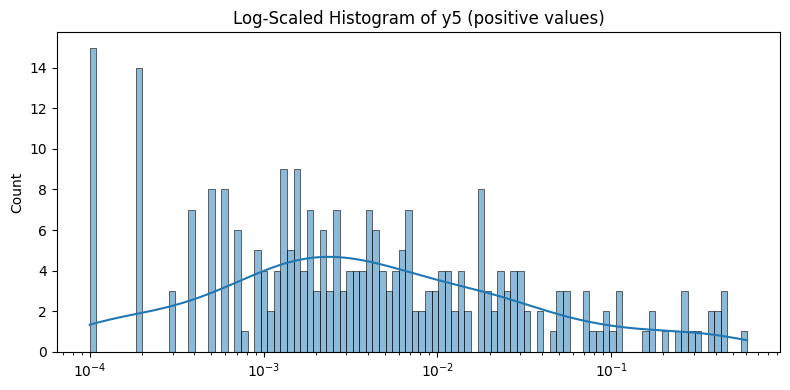


Outliers y5 (> mean + 3σ): 10 samples (3.12%)
Range: min=0.3016, max=0.6063


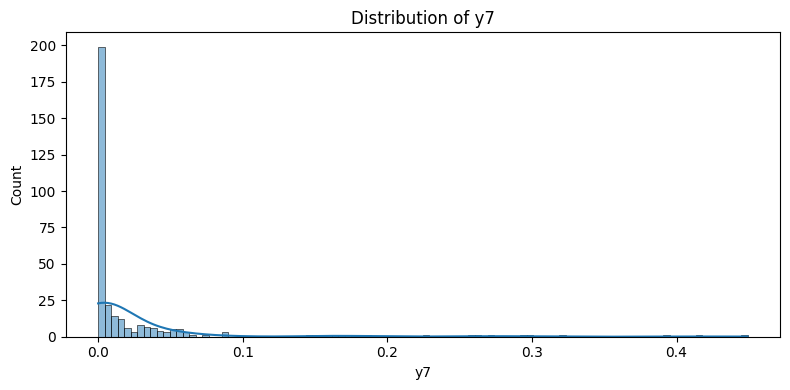

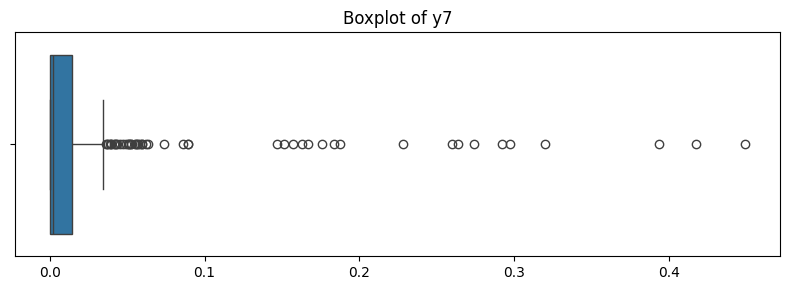

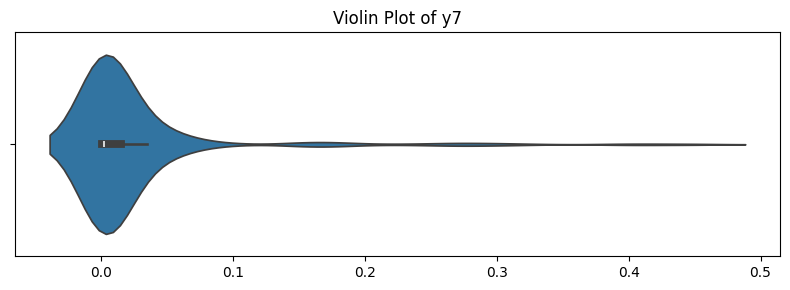

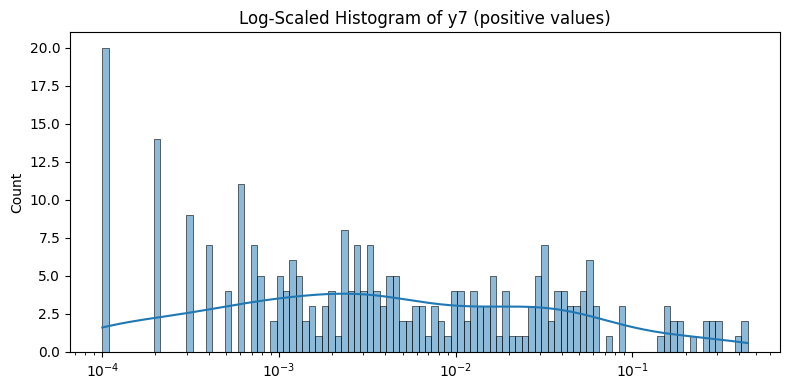


Outliers y7 (> mean + 3σ): 10 samples (3.12%)
Range: min=0.2283, max=0.4491


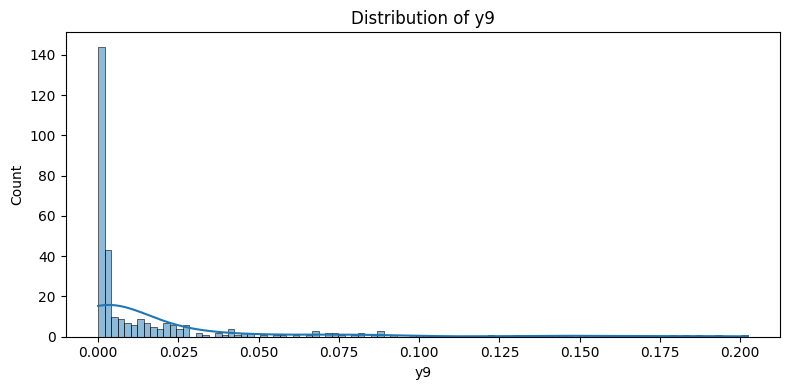

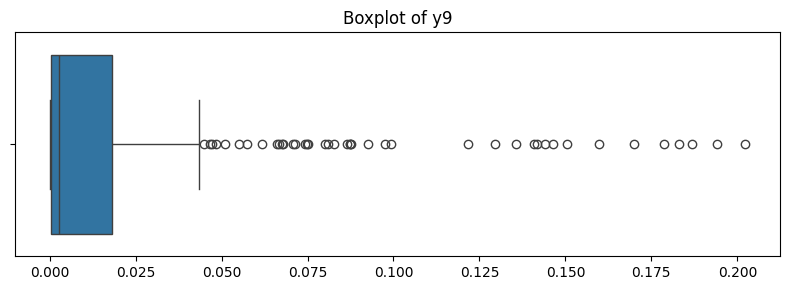

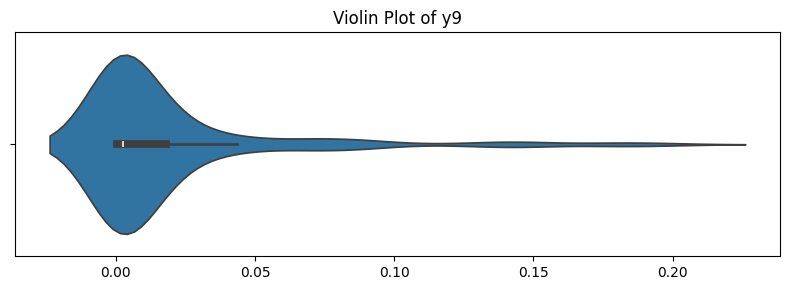

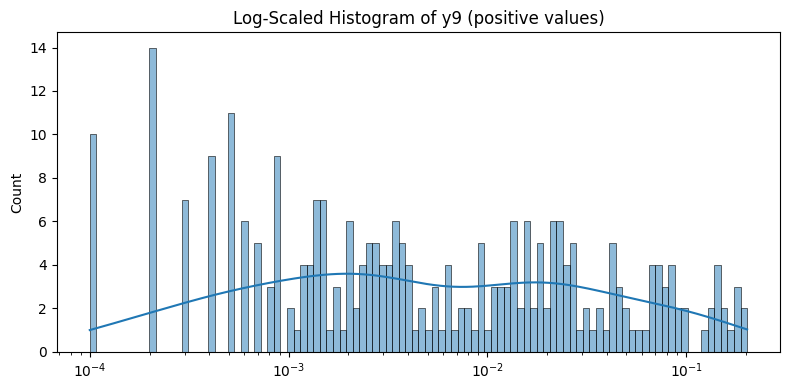


Outliers y9 (> mean + 3σ): 13 samples (4.06%)
Range: min=0.1355, max=0.2023


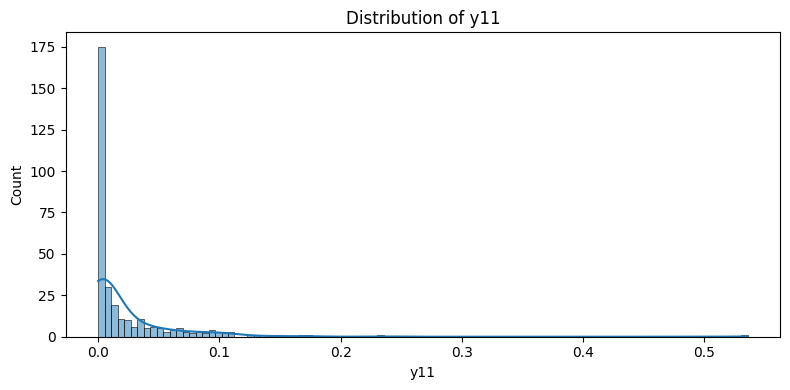

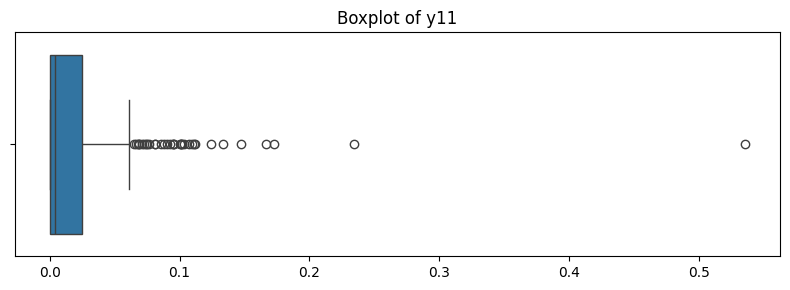

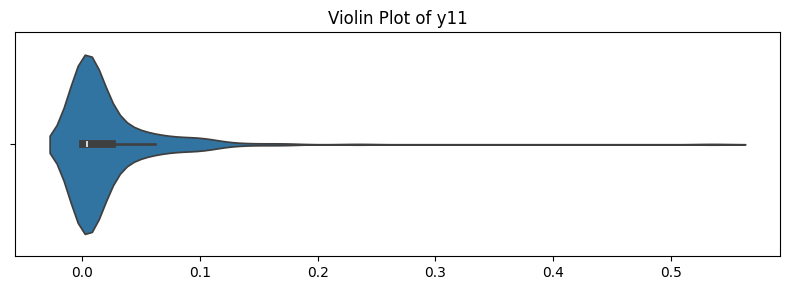

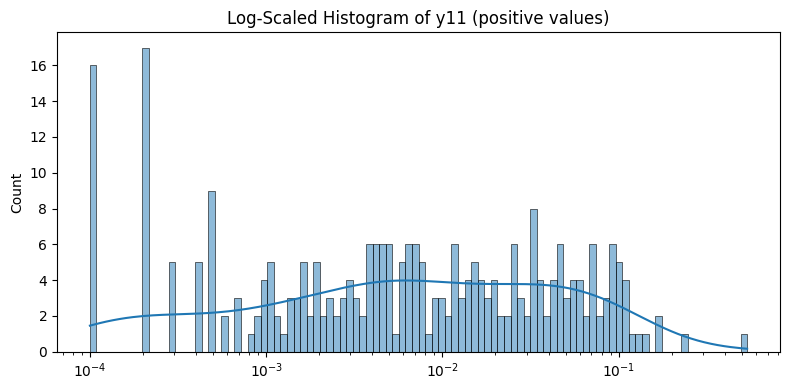


Outliers y11 (> mean + 3σ): 4 samples (1.25%)
Range: min=0.1669, max=0.5355


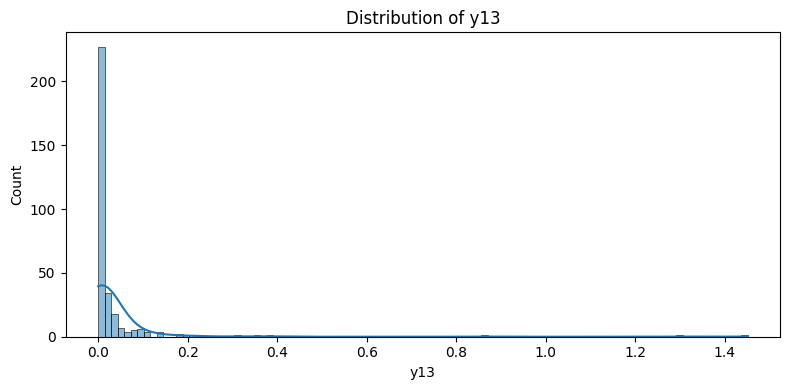

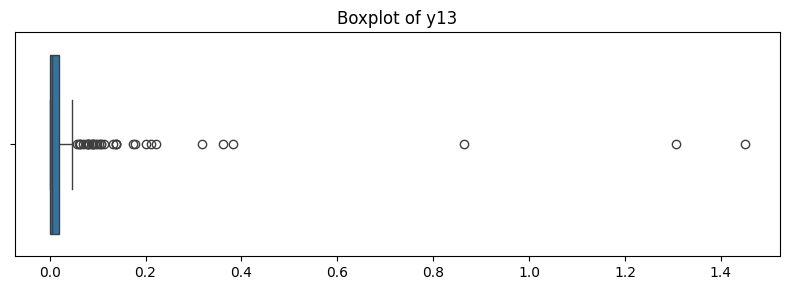

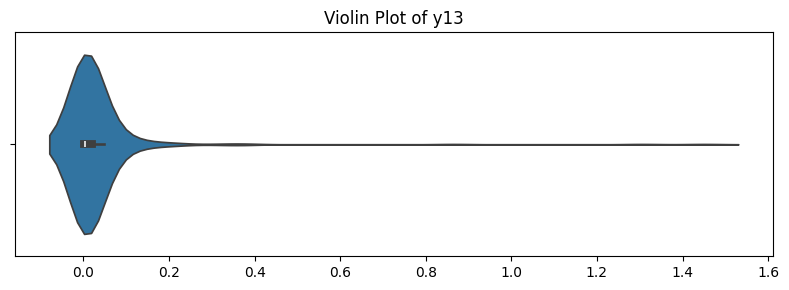

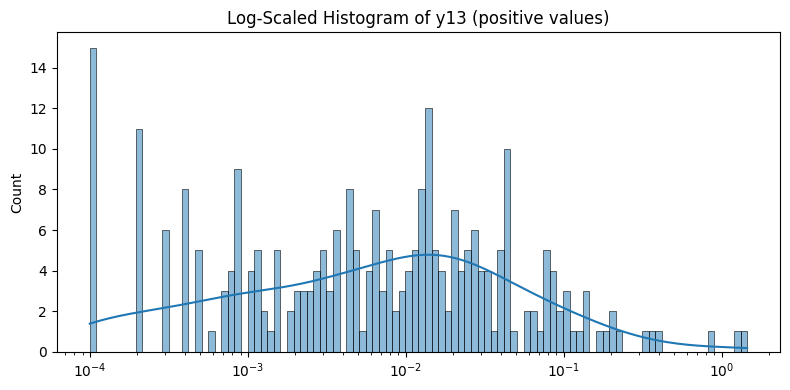


Outliers y13 (> mean + 3σ): 3 samples (0.94%)
Range: min=0.8652, max=1.4507


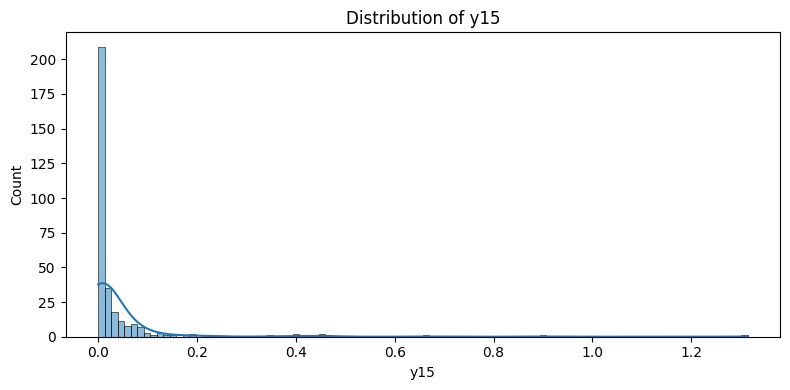

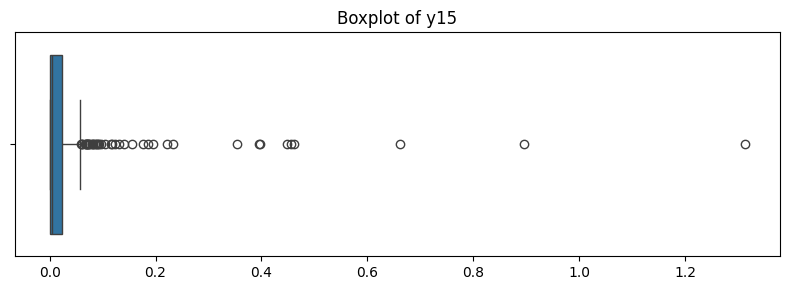

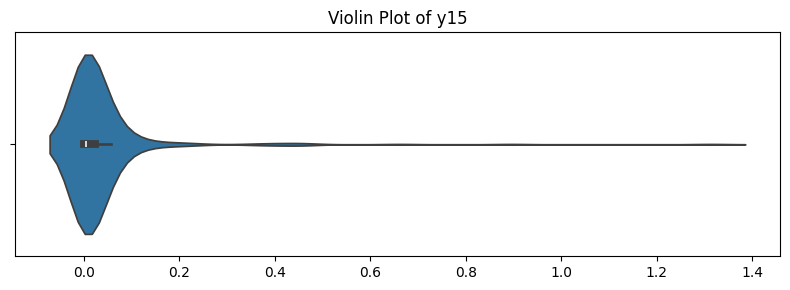

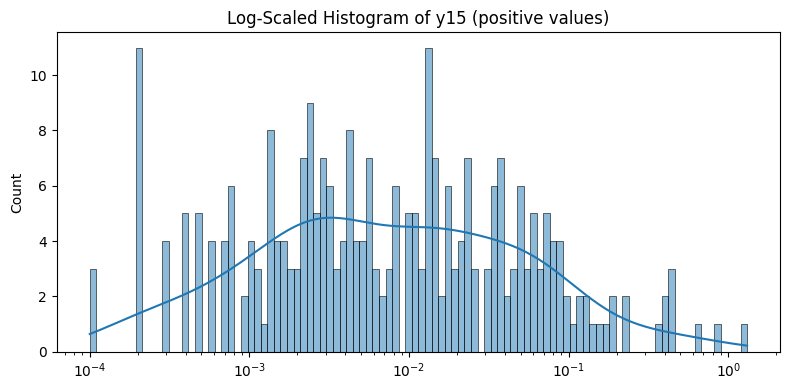


Outliers y15 (> mean + 3σ): 8 samples (2.50%)
Range: min=0.3961, max=1.3138


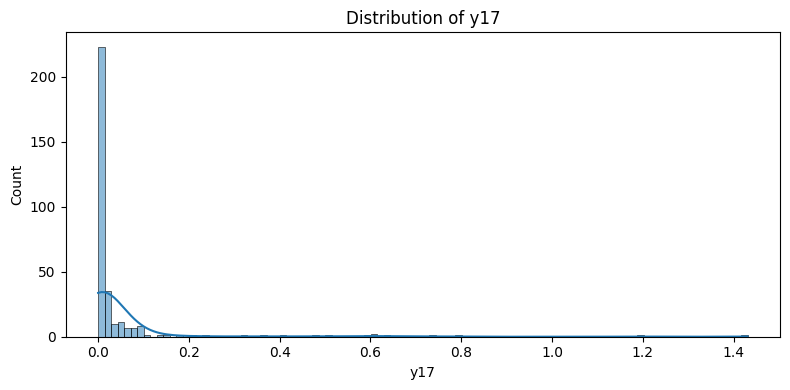

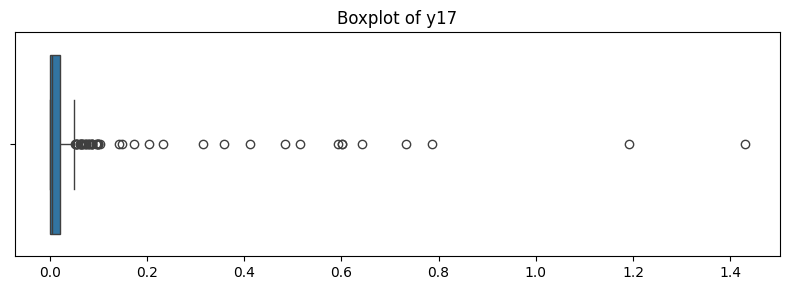

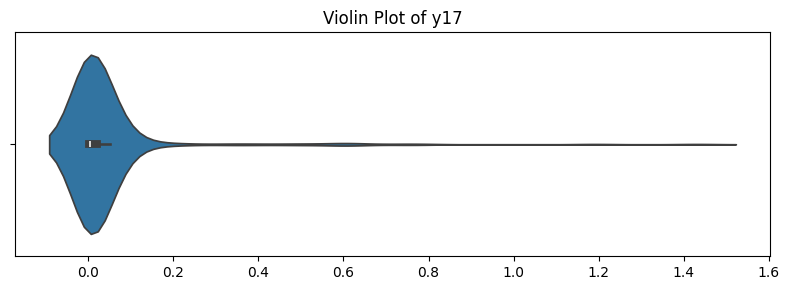

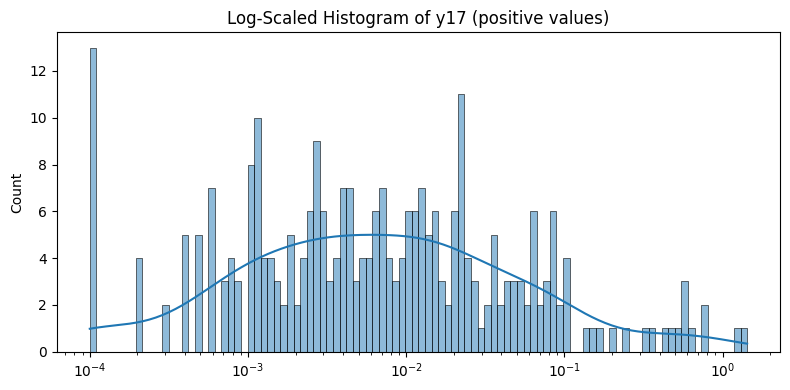


Outliers y17 (> mean + 3σ): 10 samples (3.12%)
Range: min=0.4831, max=1.4307


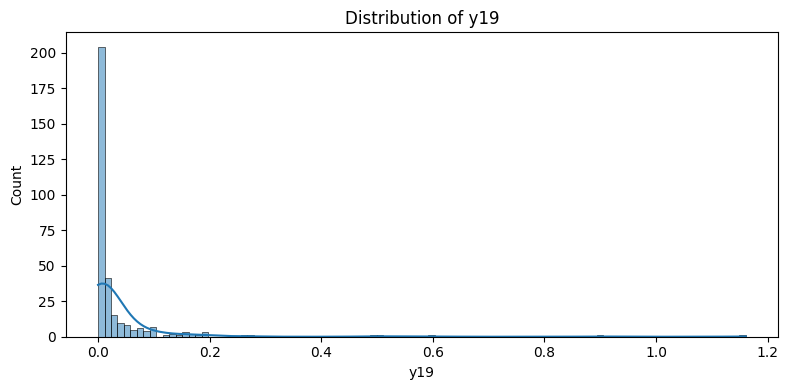

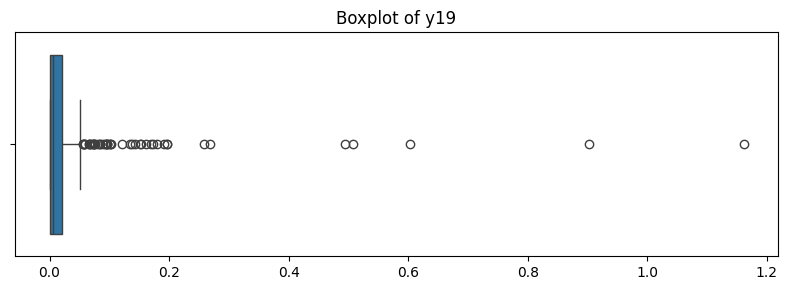

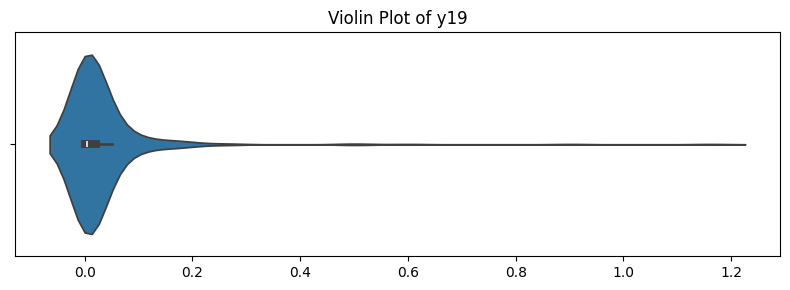

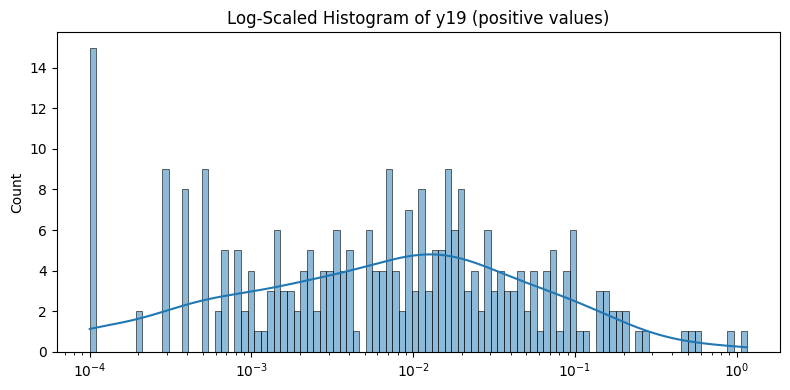


Outliers y19 (> mean + 3σ): 5 samples (1.56%)
Range: min=0.4947, max=1.1610


In [34]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 10,
    'filter_states': 10,
    'pre_transform': None
}

dataset_analysis_10 = analyze_dataset_outputs_10(
    dataset_config=dataset_config,
)


Processing...


Merged dataset: 25893 rows (from 40111 base and 74273 star)


Processing: 100%|███████████████████████| 25893/25893 [00:19<00:00, 1344.58it/s]
Done!
/tmp/ipykernel_4315/3986023085.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 10
max_resources_: 256
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 10
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resou

----------
iter: 1
n_candidates: 17
n_resources: 30
Fitting 5 folds for each of 17 candidates, totalling 85 fits
----------
iter: 2
n_candidates: 6
n_resources: 90
Fitting 5 folds for each of 6 candidates, totalling 30 fits


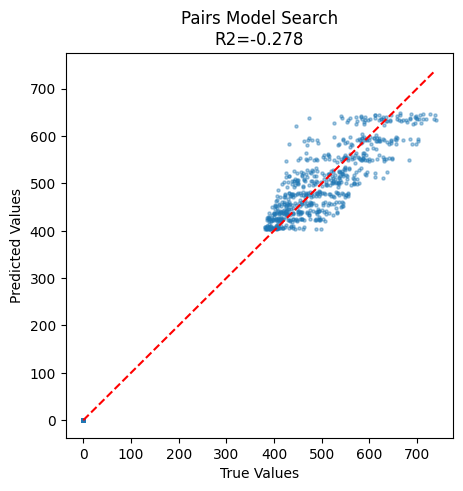

In [26]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 10,
    'filter_states': 10,
    'pre_transform': None
}

params_10_cm = find_best_hyperparams_model_only(
    dataset_config=dataset_config,
    fingerprint_fn=coulomb_fingerprint_with_labels,
    output_type="pairs",
    atoms_count=30 
)

/tmp/ipykernel_4315/2909737728.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


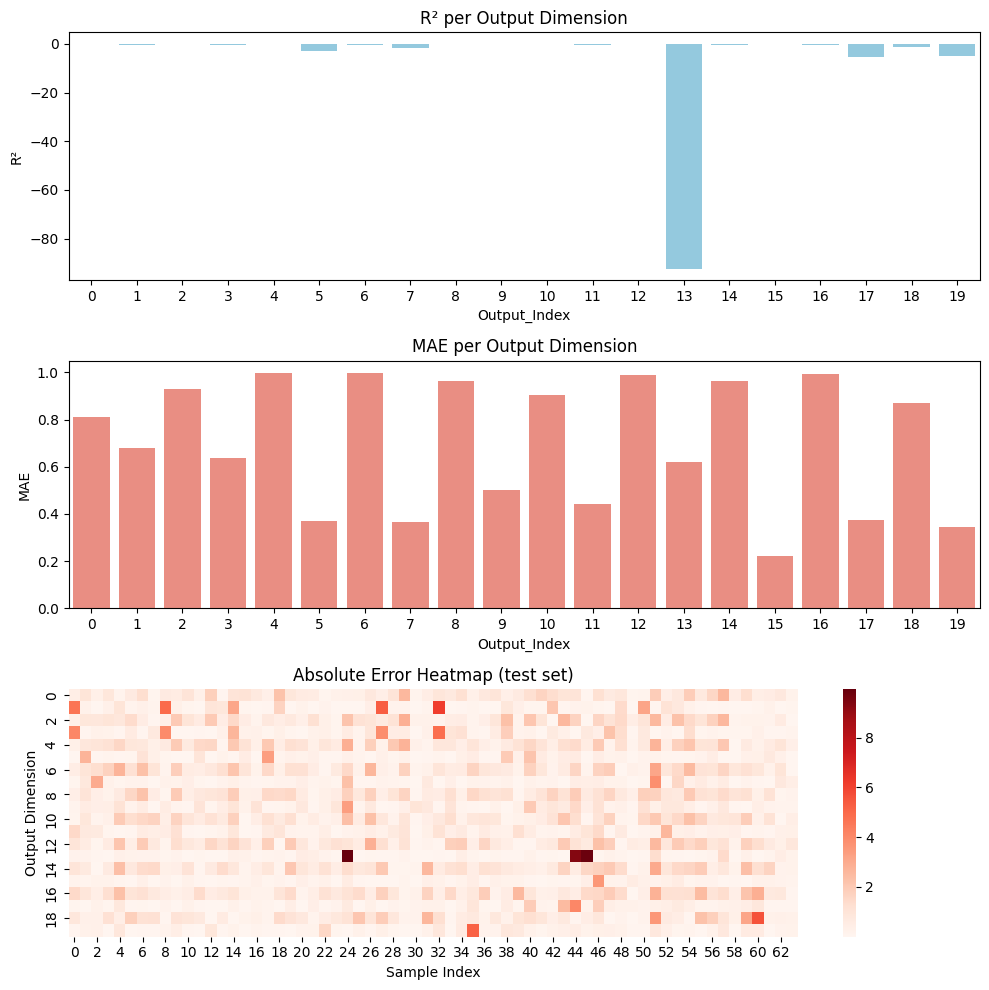

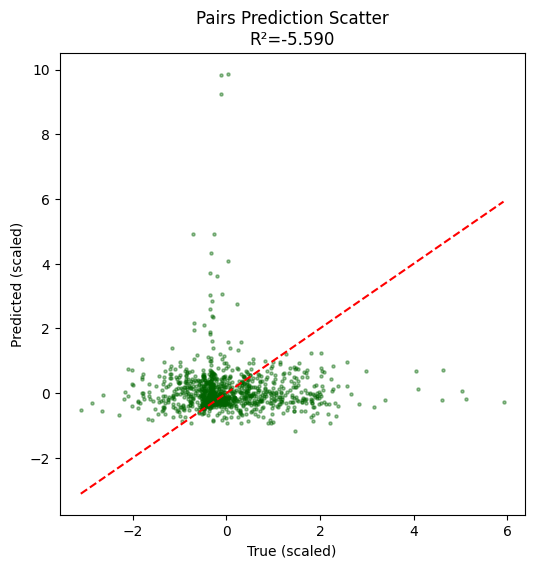


=== FINAL RESULTS ===
R2: [0.06447094678878784, -0.51806640625, -0.14812421798706055, -0.40893518924713135, -0.15675711631774902, -3.147430896759033, -0.33366692066192627, -1.9193964004516602, -0.24273478984832764, 0.0957869291305542, -0.04973649978637695, -0.5076173543930054, -0.21549451351165771, -92.3303451538086, -0.30183660984039307, -0.08395421504974365, -0.37684428691864014, -5.221428394317627, -1.1700470447540283, -4.832452774047852]
MAE: [0.8090177774429321, 0.6798722743988037, 0.928526759147644, 0.6383278965950012, 0.9963351488113403, 0.3680782914161682, 0.9995136260986328, 0.3654724359512329, 0.962537407875061, 0.501768946647644, 0.9025275707244873, 0.44051477313041687, 0.9871103763580322, 0.6181058287620544, 0.9641866087913513, 0.2234940528869629, 0.9913451671600342, 0.37285977602005005, 0.8692953586578369, 0.3445657193660736]


In [27]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 10,
    'filter_states': 10,
    'pre_transform': None
}

results_10_cm = train_fixed_model(
    dataset_config=dataset_config,
    fingerprint_fn=coulomb_fingerprint_with_labels,
    model_params=params_10_cm,
    output_type="pairs",
    atoms_count=30
)

print("\n=== FINAL RESULTS ===")
print("R2:", results_10_cm["per_target_r2"])
print("MAE:", results_10_cm["per_target_mae"])


/tmp/ipykernel_4315/3986023085.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 10
max_resources_: 256
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 10
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resou

----------
iter: 1
n_candidates: 17
n_resources: 30
Fitting 5 folds for each of 17 candidates, totalling 85 fits
----------
iter: 2
n_candidates: 6
n_resources: 90
Fitting 5 folds for each of 6 candidates, totalling 30 fits


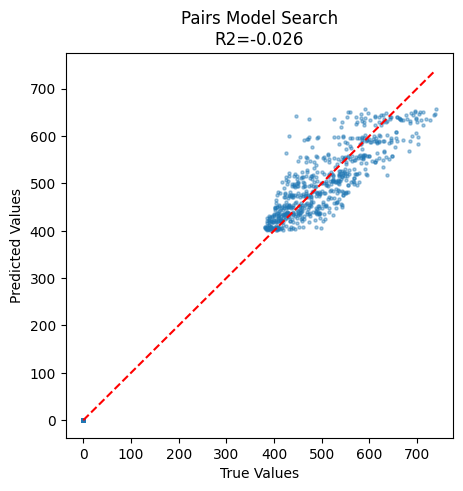

In [35]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 10,
    'filter_states': 10,
    'pre_transform': None
}

params_10_bob = find_best_hyperparams_model_only(
    dataset_config=dataset_config,
    fingerprint_fn=bag_of_bonds_fingerprint_with_labels,
    output_type="pairs",
    atoms_count=30 
)

/tmp/ipykernel_4315/2909737728.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_vec = np.array(d.y).flatten()


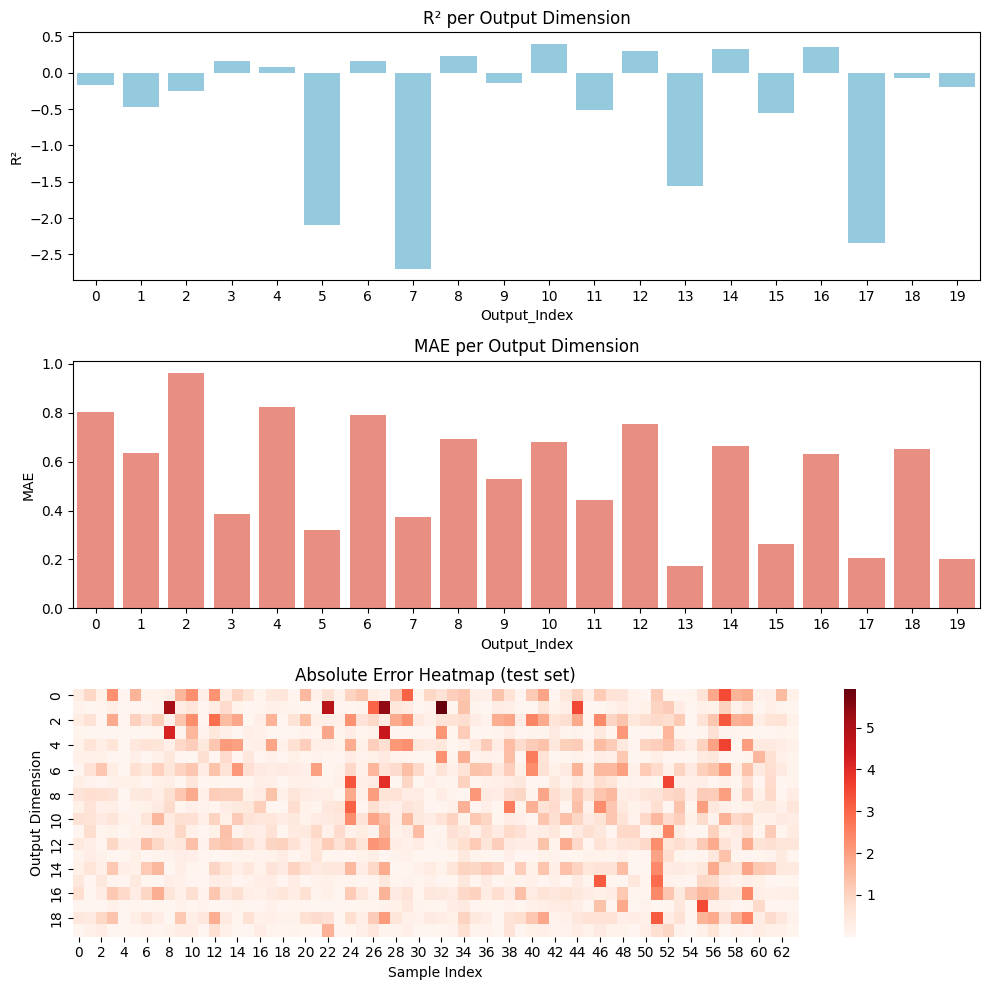

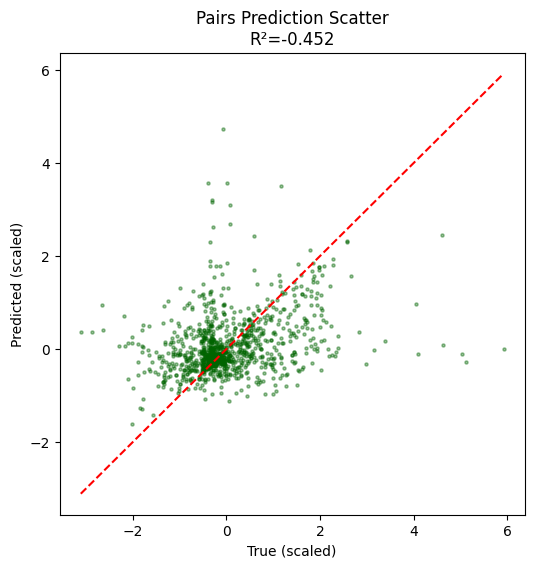


=== FINAL RESULTS ===
R2: [-0.16156935691833496, -0.4716012477874756, -0.24983704090118408, 0.15957140922546387, 0.08542543649673462, -2.0920042991638184, 0.15744447708129883, -2.6973252296447754, 0.2256075143814087, -0.14241206645965576, 0.40201324224472046, -0.5079151391983032, 0.29449009895324707, -1.5542256832122803, 0.3259437680244446, -0.5496813058853149, 0.35402560234069824, -2.3470616340637207, -0.07543480396270752, -0.1888219118118286]
MAE: [0.8018368482589722, 0.6372807025909424, 0.9650935530662537, 0.3843404948711395, 0.8255511522293091, 0.32132595777511597, 0.7895851135253906, 0.37535586953163147, 0.6927812099456787, 0.5300923585891724, 0.6807200908660889, 0.44308754801750183, 0.7557848691940308, 0.1730317324399948, 0.6626908183097839, 0.2640092372894287, 0.6324396133422852, 0.20698928833007812, 0.6525333523750305, 0.20356965065002441]


In [36]:
dataset_config = {
    'root': "data/datasets/TMQMG_star",
    'block_3_only': True,
    'prediction_type': 'pairs',
    'prediction_params': {"range": (380, 750)},
    'vis_range': (380, 750),
    'num_states': 10,
    'filter_states': 10,
    'pre_transform': None
}

results_10_bob = train_fixed_model(
    dataset_config=dataset_config,
    fingerprint_fn=bag_of_bonds_fingerprint_with_labels,
    model_params=params_10_bob,
    output_type="pairs",
    atoms_count=30
)

print("\n=== FINAL RESULTS ===")
print("R2:", results_10_bob["per_target_r2"])
print("MAE:", results_10_bob["per_target_mae"])


In [59]:
def explain_with_shap(results, output_idx=0, sample_limit=200):
    print(f"[INFO] Running SHAP analysis for output #{output_idx}")

    model = results["model"].estimators_[output_idx]
    X_train = results["X_train"]
    X_test = results["X_test"]

    feature_labels = results.get("labels", None)
    if feature_labels is not None:
        print(f"[INFO] Using {len(feature_labels)} feature labels for SHAP visualization.")
    else:
        print("[WARN] No feature labels found in results — using numeric indices.")

    if sample_limit is not None and len(X_test) > sample_limit:
        X_sample = X_test[:sample_limit]
    else:
        X_sample = X_test

    try:
        explainer = shap.TreeExplainer(model)
    except Exception:
        explainer = shap.Explainer(model)

    shap_values = explainer(X_sample)

    if feature_labels is not None and len(feature_labels) == X_sample.shape[1]:
        shap.summary_plot(shap_values, X_sample, feature_names=feature_labels, plot_type="bar", show=True)
        shap.summary_plot(shap_values, X_sample, feature_names=feature_labels, show=True)
    else:
        shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)
        shap.summary_plot(shap_values, X_sample, show=True)

    print("[INFO] SHAP analysis completed.")


[INFO] Running SHAP analysis for output #0
[WARN] No feature labels found in results — using numeric indices.


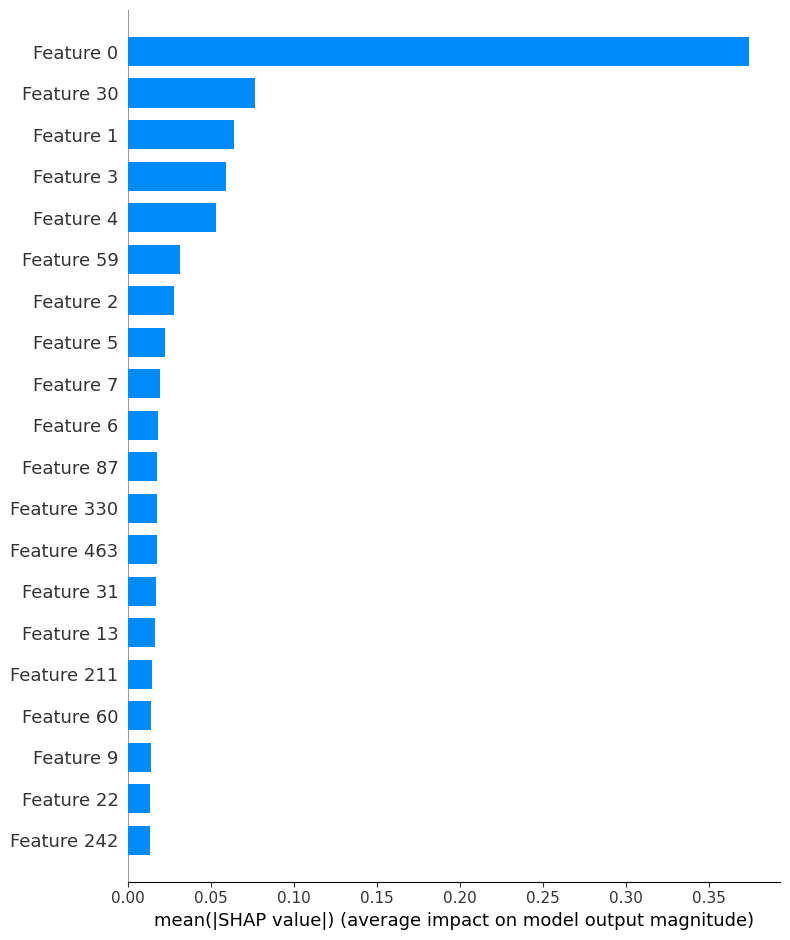

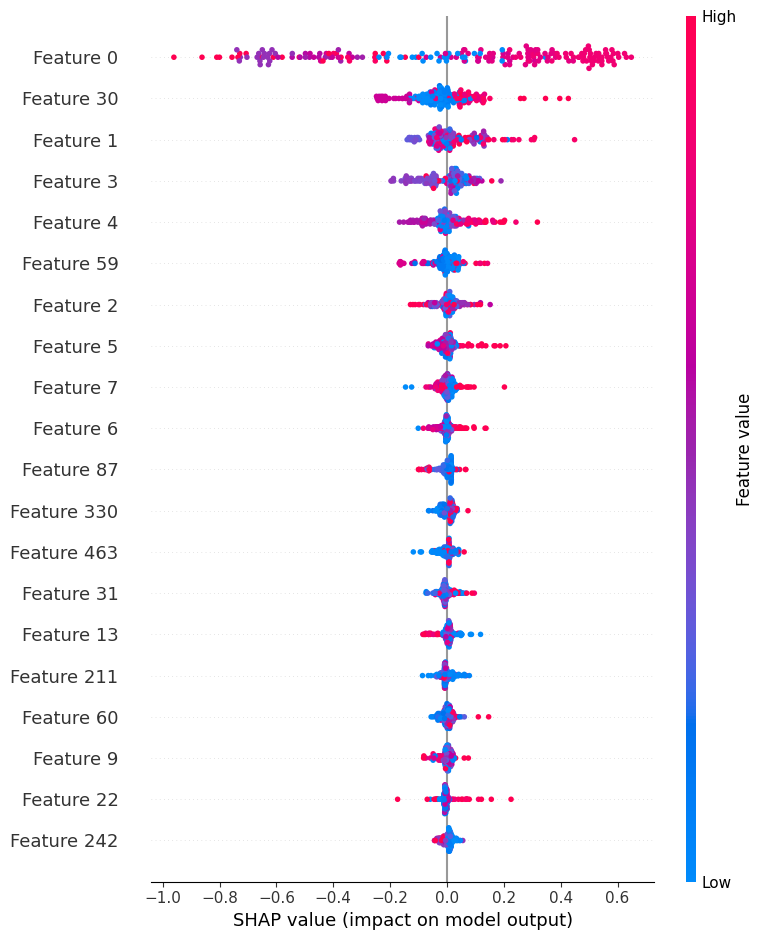

[INFO] SHAP analysis completed.


In [60]:
explain_with_shap(results)